In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611

In [4]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (302, 14)


In [5]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


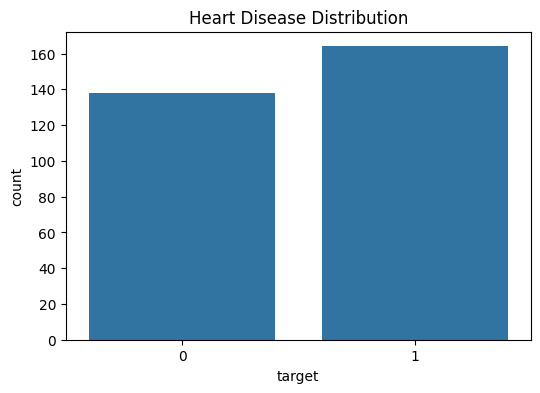

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

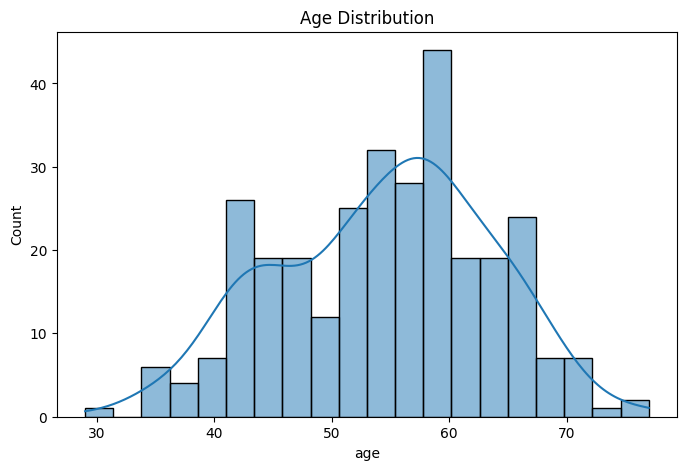

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

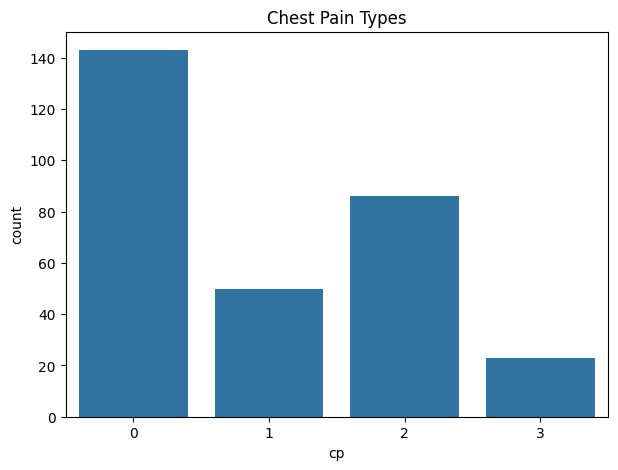

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='cp',data=df)
plt.title("Chest Pain Types")
plt.show()

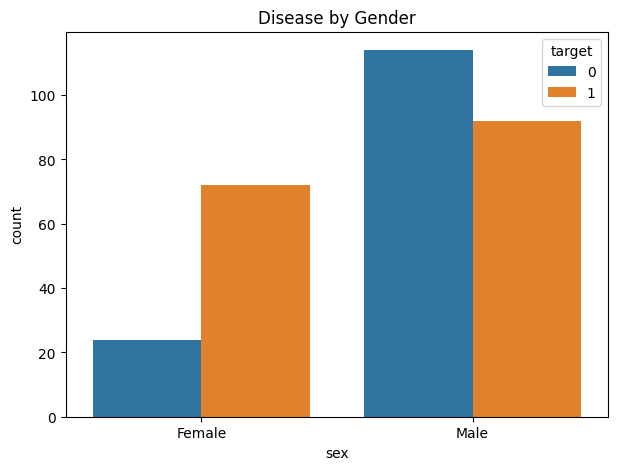

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(x='sex',
              hue='target',
              data=df)

plt.xticks([0,1],["Female","Male"])

plt.title("Disease by Gender")

plt.show()

In [12]:
print("Average Age")

print(df['age'].mean())

Average Age
54.420529801324506


In [13]:
print("Average Cholesterol")

print(df['chol'].mean())

Average Cholesterol
246.5


In [14]:
percentage = (df['target'].value_counts(normalize=True))*100

print(percentage)

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [15]:
percentage = (df['target'].value_counts(normalize=True))*100

print(percentage)

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [16]:
if 'smoke' in df.columns:
    sns.countplot(x='smoke',hue='target',data=df)
    plt.show()

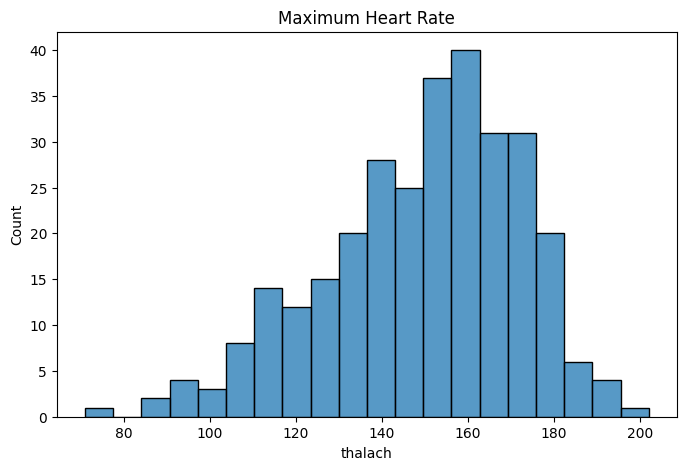

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['thalach'], bins=20)

plt.title("Maximum Heart Rate")

plt.show()

In [18]:
print("Medical Insights")
print("-"*40)

print("Average Patient Age :",round(df['age'].mean(),2))

print("Average Cholesterol :",round(df['chol'].mean(),2))

print("Average Resting BP :",round(df['trestbps'].mean(),2))

print("Disease Percentage")

print(df['target'].value_counts(normalize=True)*100)

Medical Insights
----------------------------------------
Average Patient Age : 54.42
Average Cholesterol : 246.5
Average Resting BP : 131.6
Disease Percentage
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [20]:
top=df.sort_values("age",ascending=False)

print(top[['age','sex','chol','target']].head(10))

     age  sex  chol  target
160   77    1   304       0
99    76    0   197       1
313   74    0   269       1
287   71    0   302       1
269   71    0   265       1
10    71    0   149       1
2     70    1   174       0
402   70    1   245       1
328   70    1   322       0
33    70    1   269       0


In [21]:
df.to_csv("cleaned_heart.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [24]:
report = f"""
Healthcare Data Analysis Report
===============================

Total Patients : {len(df)}

Average Age : {round(df['age'].mean(), 2)}

Average Cholesterol : {round(df['chol'].mean(), 2)}

Average Blood Pressure : {round(df['trestbps'].mean(), 2)}

Disease Percentage:

{df['target'].value_counts(normalize=True) * 100}

Conclusion

1. Most patients are middle-aged to older adults.
2. Patients with heart disease generally have higher risk factors.
3. Cholesterol and blood pressure are important indicators.
4. Age and gender influence disease occurrence.
5. Regular health checkups can help detect heart disease early.
"""

print(report)

with open("Medical_Insights_Report.txt", "w") as file:
    file.write(report)

print("Report Generated Successfully!")


Healthcare Data Analysis Report

Total Patients : 302

Average Age : 54.42

Average Cholesterol : 246.5

Average Blood Pressure : 131.6

Disease Percentage:

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

Conclusion

1. Most patients are middle-aged to older adults.
2. Patients with heart disease generally have higher risk factors.
3. Cholesterol and blood pressure are important indicators.
4. Age and gender influence disease occurrence.
5. Regular health checkups can help detect heart disease early.

Report Generated Successfully!
